<a href="https://colab.research.google.com/github/neeyatlotlikar/me_fy_project/blob/dev/ADF_ReRanking_MIND.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prerequisites and Dataset

In [ ]:
!pip install implicit pandas numpy scipy gensim umap-learn hdbscan -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.3/70.3 kB 2.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 67.2 MB/s eta 0:00:00


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/ME_PROJECT/Implementation

/content/drive/MyDrive/ME_PROJECT/Implementation


In [ ]:
!mkdir -p data
%cd data

/content/drive/MyDrive/ME_PROJECT/Implementation/data


In [3]:
model_save_path = "/content/drive/MyDrive/ME_PROJECT/Implementation/models"

I manually downloaded the dataset and uploaded the zip file to drive since it was not possible to directly download to google colab.

In [ ]:
# Unzip
!unzip MINDsmall_train.zip
!unzip MINDsmall_dev.zip

%cd ..

Archive:  MINDsmall_train.zip
   creating: MINDsmall_train/
  inflating: MINDsmall_train/behaviors.tsv  
  inflating: MINDsmall_train/news.tsv  
  inflating: MINDsmall_train/entity_embedding.vec  
  inflating: MINDsmall_train/relation_embedding.vec  
Archive:  MINDsmall_dev.zip
   creating: MINDsmall_dev/
  inflating: MINDsmall_dev/behaviors.tsv  
  inflating: MINDsmall_dev/news.tsv  
  inflating: MINDsmall_dev/entity_embedding.vec  
  inflating: MINDsmall_dev/relation_embedding.vec  
/content/drive/MyDrive/ME_PROJECT/Implementation


In [ ]:
!ls -lh data/

total 1.3G
-rw------- 1 root root  99M Feb 23 07:38 MINDlarge_dev.zip
-rw------- 1 root root 577M Feb 23 07:40 MINDlarge_test.zip
-rw------- 1 root root 506M Feb 23 07:39 MINDlarge_train.zip
drwx------ 2 root root 4.0K Aug 11  2024 MINDsmall_dev
-rw------- 1 root root  30M Feb 23 07:40 MINDsmall_dev.zip
drwx------ 2 root root 4.0K Aug 11  2024 MINDsmall_train
-rw------- 1 root root  51M Feb 23 07:40 MINDsmall_train.zip


In [ ]:
!ls -lh data/MINDsmall_dev

total 95M
-rw------- 1 root root   41M Aug 11  2024 behaviors.tsv
-rw------- 1 root root   21M Aug 11  2024 entity_embedding.vec
-rw------- 1 root root   32M Aug 11  2024 news.tsv
-rw------- 1 root root 1021K Aug 11  2024 relation_embedding.vec


In [ ]:
!ls -lh data/MINDsmall_train

total 153M
-rw------- 1 root root   88M Aug 11  2024 behaviors.tsv
-rw------- 1 root root   25M Aug 11  2024 entity_embedding.vec
-rw------- 1 root root   40M Aug 11  2024 news.tsv
-rw------- 1 root root 1021K Aug 11  2024 relation_embedding.vec


In [ ]:
!head -n 3 data/MINDsmall_train/news.tsv

N55528	lifestyle	lifestyleroyals	The Brands Queen Elizabeth, Prince Charles, and Prince Philip Swear By	Shop the notebooks, jackets, and more that the royals can't live without.	https://assets.msn.com/labs/mind/AAGH0ET.html	[{"Label": "Prince Philip, Duke of Edinburgh", "Type": "P", "WikidataId": "Q80976", "Confidence": 1.0, "OccurrenceOffsets": [48], "SurfaceForms": ["Prince Philip"]}, {"Label": "Charles, Prince of Wales", "Type": "P", "WikidataId": "Q43274", "Confidence": 1.0, "OccurrenceOffsets": [28], "SurfaceForms": ["Prince Charles"]}, {"Label": "Elizabeth II", "Type": "P", "WikidataId": "Q9682", "Confidence": 0.97, "OccurrenceOffsets": [11], "SurfaceForms": ["Queen Elizabeth"]}]	[]
N19639	health	weightloss	50 Worst Habits For Belly Fat	These seemingly harmless habits are holding you back and keeping you from shedding that unwanted belly fat for good.	https://assets.msn.com/labs/mind/AAB19MK.html	[{"Label": "Adipose tissue", "Type": "C", "WikidataId": "Q193583", "Confidence": 1.0

In [ ]:
!head -n 3 data/MINDsmall_train/behaviors.tsv

1	U13740	11/11/2019 9:05:58 AM	N55189 N42782 N34694 N45794 N18445 N63302 N10414 N19347 N31801	N55689-1 N35729-0
2	U91836	11/12/2019 6:11:30 PM	N31739 N6072 N63045 N23979 N35656 N43353 N8129 N1569 N17686 N13008 N21623 N6233 N14340 N48031 N62285 N44383 N23061 N16290 N6244 N45099 N58715 N59049 N7023 N50528 N42704 N46082 N8275 N15710 N59026 N8429 N30867 N56514 N19709 N31402 N31741 N54889 N9798 N62612 N2663 N16617 N6087 N13231 N63317 N61388 N59359 N51163 N30698 N34567 N54225 N32852 N55833 N64467 N3142 N13912 N29802 N44462 N29948 N4486 N5398 N14761 N47020 N65112 N31699 N37159 N61101 N14761 N3433 N10438 N61355 N21164 N22976 N2511 N48390 N58224 N48742 N35458 N24611 N37509 N21773 N41011 N19041 N25785	N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N22407-0 N14592-0 N17059-1 N33677-0 N7821-0 N6890-0
3	U73700	11/14/2019 7:01:48 AM	N10732 N25792 N7563 N21087 N41087 N5445 N60384 N46616 N52500 N33164 N47289 N24233 N62058 N26378 N49475 N18870	N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N59685-0 N23814-

In [ ]:
!file data/MINDsmall_train/entity_embedding.vec

data/MINDsmall_train/entity_embedding.vec: ASCII text, with very long lines (970)


In [ ]:
!head -n 5 data/MINDsmall_train/entity_embedding.vec

Q41	-0.063388	-0.181451	0.057501	-0.091254	-0.076217	-0.052525	0.050500	-0.224871	-0.018145	0.030722	0.064276	0.073063	0.039489	0.159404	-0.128784	0.016325	0.026797	0.137090	0.001849	-0.059103	0.012091	0.045418	0.000591	0.211337	-0.034093	-0.074582	0.014004	-0.099355	0.170144	0.109376	-0.014797	0.071172	0.080375	0.045563	-0.046462	0.070108	0.015413	-0.020874	-0.170324	-0.001130	0.059810	0.054342	0.027358	-0.028995	-0.224508	0.066281	-0.200006	0.018186	0.082396	0.167178	-0.136239	0.055134	-0.080195	-0.001460	0.031078	-0.017084	-0.091176	-0.036916	0.124642	-0.098185	-0.054836	0.152483	-0.053712	0.092816	-0.112044	-0.072247	-0.114896	-0.036541	-0.186339	-0.160610	0.037342	-0.133474	0.110080	0.070678	-0.005586	-0.046667	-0.072010	0.086424	0.026165	0.030561	0.077888	-0.117226	0.211597	0.112512	0.079999	-0.083398	-0.121117	0.071751	-0.017654	-0.134979	-0.051949	0.001861	0.124535	-0.151043	-0.263698	-0.103607	0.020007	-0.101157	-0.091567	0.035234	
Q1860	0.060958	0.069934	0.015832	0.079471	-0.

In [ ]:
df = pd.read_csv('data/MINDsmall_train/behaviors.tsv', sep='\t', index_col=0, nrows=25, header=None)
df.head()

,1,2,3,4
0,,,,
1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689-1 N35729-0
2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...
3,U73700,11/14/2019 7:01:48 AM,N10732 N25792 N7563 N21087 N41087 N5445 N60384...,N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N...
4,U34670,11/11/2019 5:28:05 AM,N45729 N2203 N871 N53880 N41375 N43142 N33013 ...,N35729-0 N33632-0 N49685-1 N27581-0
5,U8125,11/12/2019 4:11:21 PM,N10078 N56514 N14904 N33740,N39985-0 N36050-0 N16096-0 N8400-1 N22407-0 N6...


In [ ]:
import pandas as pd

# Peek at files
for split in ['data/MINDsmall_dev', 'data/MINDsmall_train']:
  print(f"{split} News file shape:", pd.read_csv(f'{split}/news.tsv', sep='\t', nrows=3).shape)
  print("Interactions files:")
  df = pd.read_csv(f'{split}/behaviors.tsv', sep='\t', nrows=1000, header=None)
  print(f"  behaviors.tsv: {len(df)} rows, {df[1].nunique()} users, {df[2].nunique()} click history, {df[3].nunique()} impressions")
  for f in ['entity_embedding.vec', 'relation_embedding.vec']:
    df = pd.read_csv(f'{split}/{f}', sep='\t', nrows=1000, header=None)
    print(f"  {f}: {df.shape} shape, {df.iloc[:5, 0].tolist()} sample ids, {df.shape[1] - 1} vector dimensions")
  print()


data/MINDsmall_dev News file shape: (3, 8)
Interactions files:
  behaviors.tsv: 1000 rows, 996 users, 994 click history, 961 impressions
  entity_embedding.vec: (1000, 102) shape, ['Q34433', 'Q41', 'Q56037', 'Q1860', 'Q39631'] sample ids, 101 vector dimensions
  relation_embedding.vec: (1000, 102) shape, ['P31', 'P21', 'P106', 'P735', 'P108'] sample ids, 101 vector dimensions

data/MINDsmall_train News file shape: (3, 8)
Interactions files:
  behaviors.tsv: 1000 rows, 988 users, 1000 click history, 974 impressions
  entity_embedding.vec: (1000, 102) shape, ['Q41', 'Q1860', 'Q39631', 'Q30', 'Q60'] sample ids, 101 vector dimensions
  relation_embedding.vec: (1000, 102) shape, ['P31', 'P21', 'P106', 'P735', 'P108'] sample ids, 101 vector dimensions



In [ ]:
import implicit
print("Implicit version:", implicit.__version__)
help(implicit.bpr.BayesianPersonalizedRanking)

Implicit version: 0.7.2
Help on function BayesianPersonalizedRanking in module implicit.bpr:

BayesianPersonalizedRanking(factors=100, learning_rate=0.01, regularization=0.01, dtype=<class 'numpy.float32'>, iterations=100, use_gpu=False, num_threads=0, verify_negative_samples=True, random_state=None)
    Bayesian Personalized Ranking

    A recommender model that learns  a matrix factorization embedding based off minimizing the
    pairwise ranking loss described in the paper `BPR: Bayesian Personalized Ranking from Implicit
    Feedback <https://arxiv.org/pdf/1205.2618.pdf>`_.

    This factory function returns either the cpu implementation from implicit.cpu.bpr or
    the gpu implementation from implicit.gpu.bpr depending on the value of the use_gpu flag.

    Parameters
    ----------
    factors : int, optional
        The number of latent factors to compute
    learning_rate : float, optional
        The learning rate to apply for SGD updates during training
    regularization : f

# Load & Explore MIND Data Structure

In [ ]:
import pandas as pd
import numpy as np

print("Loading MIND Data...")
behv_cols = ['impr_id', 'user_id', 'time', 'hist', 'imprs']
train_beh = pd.read_csv('data/MINDsmall_train/behaviors.tsv', sep='\t', names=behv_cols, nrows=10000)
dev_beh = pd.read_csv('data/MINDsmall_dev/behaviors.tsv', sep='\t', names=behv_cols, nrows=10000)

news_cols = ['news_id', 'category', 'subcategory', 'title', 'abstract', 'url', 'title_entities', 'abstract_entities']
train_news = pd.read_csv('data/MINDsmall_train/news.tsv', sep='\t', names=news_cols, nrows=10000)
dev_news = pd.read_csv('data/MINDsmall_dev/news.tsv', sep='\t', names=news_cols, nrows=10000)

print(f"  Train: {len(train_beh)} impressions, {train_beh['user_id'].nunique()} users")
print(f"  Dev:   {len(dev_beh)} impressions, {dev_beh['user_id'].nunique()} users")
print(f"  Train news: {len(train_news)} articles")
print(f"  Dev news: {len(dev_news)} articles")

print("\nBehaviors sample:")
print(train_beh.head(2))
print("\nNews sample:")
print(train_news.head(2))


Loading MIND Data...
  Train: 10000 impressions, 8683 users
  Dev:   10000 impressions, 9382 users
  Train news: 10000 articles
  Dev news: 10000 articles

Behaviors sample:
   impr_id user_id                   time  \
0        1  U13740  11/11/2019 9:05:58 AM   
1        2  U91836  11/12/2019 6:11:30 PM   

                                                hist  \
0  N55189 N42782 N34694 N45794 N18445 N63302 N104...   
1  N31739 N6072 N63045 N23979 N35656 N43353 N8129...   

                                               imprs  
0                                  N55689-1 N35729-0  
1  N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...  

News sample:
  news_id   category      subcategory  \
0  N55528  lifestyle  lifestyleroyals   
1  N19639     health       weightloss   

                                               title  \
0  The Brands Queen Elizabeth, Prince Charles, an...   
1                      50 Worst Habits For Belly Fat   

                                            abstr

In [ ]:
# Sample dev user
dev_sample_user = list(dev_user_news.keys())[80]
dev_true_items = dev_user_news[dev_sample_user]
dev_user_idx = user_to_idx.get(dev_sample_user, 0)
print(f"\nSample dev user {dev_sample_user} clicked {len(dev_true_items)} items")
print("True clicks:", dev_true_items[:5])


Sample dev user U65757 clicked 2 items
True clicks: ['N28307', 'N21484']


In [ ]:
def parse_impressions(impr_str):
    """Parse MIND 'N123-1 N456-0' → list of (news_id, clicked)"""
    items = impr_str.split()
    news_ids = [item.split('-')[0] for item in items]
    clicks = [int(item.split('-')[1]) for item in items]
    return list(zip(news_ids, clicks))

# Test parsing
sample_impr = train_beh['imprs'].iloc[0]
parsed = parse_impressions(sample_impr)

print("Sample impression:", sample_impr[:50]+"...")
print("Parsed clicks:", parsed[:5])
print(f"\nFound {sum(c[1] for c in parsed)} clicks in this impression")

# Count clicks across sample
train_sample = train_beh.head(100)
total_clicks = 0
for impr in train_sample['imprs']:
    clicks = parse_impressions(impr)
    total_clicks += sum(c[1] for c in clicks)

print(f"\nSample stats: {total_clicks} total clicks in 100 impressions")


Sample impression: N55689-1 N35729-0...
Parsed clicks: [('N55689', 1), ('N35729', 0)]

Found 1 clicks in this impression

Sample stats: 137 total clicks in 100 impressions


# Using Implicit only

## Without Data Cleanup

### Data Categories and Sub-Categories Visualization

In [ ]:
!pip install wordcloud -q

In [ ]:
combined_news = pd.concat([train_news, dev_news], ignore_index=True)
print(f"Combined news dataframe shape: {combined_news.shape}")

categories = combined_news['category']
subcategories = combined_news['subcategory']

print("Categories head:", categories.head())
print("Subcategories head:", subcategories.head())

Combined news dataframe shape: (20000, 8)
Categories head: 0    lifestyle
1       health
2         news
3       health
4       health
Name: category, dtype: object
Subcategories head: 0    lifestyleroyals
1         weightloss
2          newsworld
3             voices
4            medical
Name: subcategory, dtype: object


In [ ]:
print("Category Value Counts:\n", categories.value_counts().head(10))
print("\nSubcategory Value Counts:\n", subcategories.value_counts().head(10))

Category Value Counts:
 category
news            5070
sports          4832
lifestyle       1614
finance         1356
foodanddrink    1300
health          1210
autos            933
travel           880
video            722
weather          599
Name: count, dtype: int64

Subcategory Value Counts:
 subcategory
football_nfl                2042
newsus                      1907
newspolitics                 936
newscrime                    726
newsworld                    619
weathertopstories            599
baseball_mlb                 569
football_ncaa                518
basketball_nba               452
newsscienceandtechnology     387
Name: count, dtype: int64


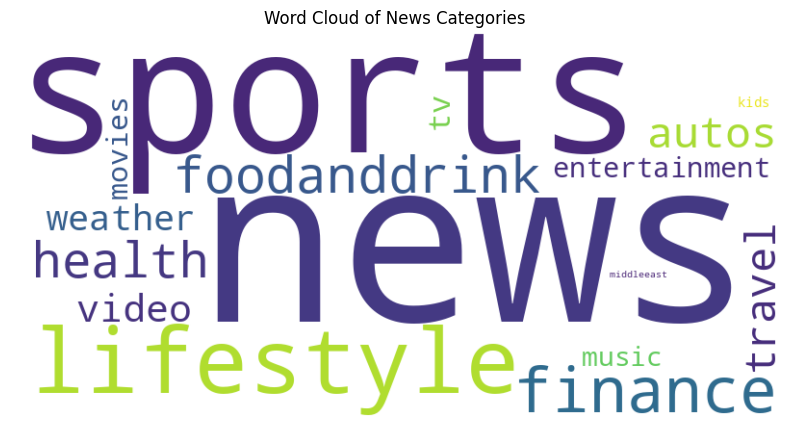

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Generate word cloud for categories
category_wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(categories.value_counts())

plt.figure(figsize=(10, 5))
plt.imshow(category_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of News Categories')
plt.show()


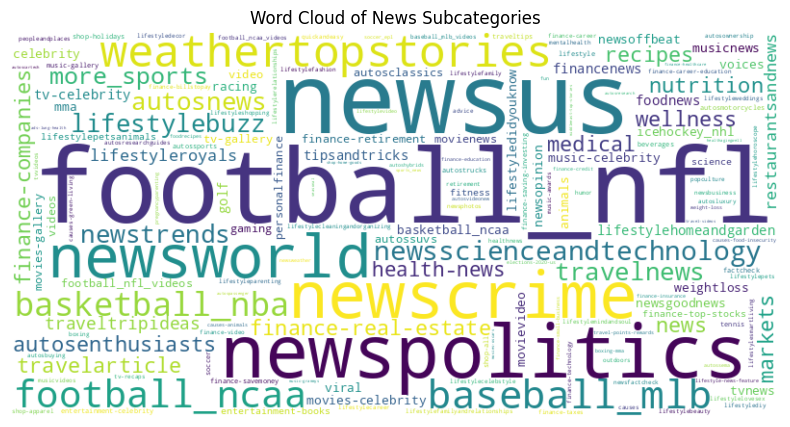

In [ ]:
subcategory_wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(subcategories.value_counts())

plt.figure(figsize=(10, 5))
plt.imshow(subcategory_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of News Subcategories')
plt.show()

### Build CF Matrix

In [ ]:
from collections import defaultdict
from scipy.sparse import coo_matrix
import numpy as np

def parse_impressions(impr_str):
    """N123-1 → [('N123', 1)]"""
    if pd.isna(impr_str):
        return []
    items = impr_str.split()
    news_ids = [item.split('-')[0] for item in items]
    clicks = [int(item.split('-')[1]) for item in items]
    return [(nid, click) for nid, click in zip(news_ids, clicks) if click == 1]

# Extract ALL positive clicks from train
print("Extracting positive clicks from train_beh...")
user_news = defaultdict(list)
news_to_idx = {}
user_to_idx = {}

for _, row in train_beh.iterrows():
    clicks = parse_impressions(row['imprs'])
    for news_id, _ in clicks:
        user_news[row['user_id']].append(news_id)

print(f"Extracted {sum(len(nlist) for nlist in user_news.values())} total clicks")
print(f"{len(user_news)} users, {len(set(news_id for nlist in user_news.values() for news_id in nlist))} unique news")

# Create user/news mappings (for matrix indices)
users = sorted(user_news.keys())
news = sorted(set(news_id for nlist in user_news.values() for news_id in nlist))
user_to_idx = {u:i for i,u in enumerate(users)}
news_to_idx = {n:i for i,n in enumerate(news)}

print(f"Mappings ready: {len(users)} users × {len(news)} news")


Extracting positive clicks from train_beh...
Extracted 14940 total clicks
8683 users, 2645 unique news
Mappings ready: 8683 users × 2645 news


In [ ]:
# Build sparse matrix for Implicit CF
rows = []
cols = []
data = []

for user_id, news_list in user_news.items():
    u_idx = user_to_idx[user_id]
    for news_id in news_list:
        n_idx = news_to_idx[news_id]
        rows.append(u_idx)
        cols.append(n_idx)
        data.append(1.0)  # confidence (all clicks = confidence 1.0)

# Create sparse matrix
user_item_matrix = coo_matrix((data, (rows, cols)),
                             shape=(len(users), len(news))).tocsr()

print(f"Sparse matrix built!")
print(f"Shape: {user_item_matrix.shape}")
print(f"Non-zero entries: {user_item_matrix.nnz}")
print(f"Density: {user_item_matrix.nnz/(user_item_matrix.shape[0]*user_item_matrix.shape[1]):.2%}")


Sparse matrix built!
Shape: (8683, 2645)
Non-zero entries: 14928
Density: 0.06%


In [ ]:
#@title Set model path before training
model_path = "/content/drive/MyDrive/ME_PROJECT/Implementation/models/bpr_model_v2.npz"

In [ ]:
#@title Model Definition
import implicit
from implicit.bpr import BayesianPersonalizedRanking
import numpy as np

# Create BPR model
model = BayesianPersonalizedRanking(
    factors=64,
    regularization=0.01,
    iterations=30,
    use_gpu=False  # Colab CPU
)

In [ ]:
#@title Model V2
model = BayesianPersonalizedRanking(
    factors=128,
    regularization=0.005,
    iterations=50,
    use_gpu=False  # Colab CPU
)

In [ ]:
# Training
model.fit(user_item_matrix, show_progress=True)
model.save(model_path)

print(f"User embeddings shape: {model.user_factors.shape}")
print(f"News embeddings shape: {model.item_factors.shape}")


  0%|          | 0/50 [00:00<?, ?it/s]

User embeddings shape: (8683, 129)
News embeddings shape: (2645, 129)


In [ ]:
#@title Load Saved Model
model.load(model_path)
print(f"Loaded {model_path}!")
print("User factors:", model.user_factors.shape)


In [ ]:
# Pick first test user
test_user_id = dev_beh['user_id'].iloc[0]
test_user_idx = user_to_idx.get(test_user_id, 0)

# Get Top-20 recommendations
scores = model.recommend(test_user_idx, user_item_matrix[test_user_idx],
                        N=20, filter_already_liked_items=True)

# Convert indices back to news IDs
top_news_idx = scores[0].argsort()[-20:][::-1]
top_news_ids = [news[idx] for idx in top_news_idx]

print(f"Top-20 recs for user {test_user_id}:")
for i, nid in enumerate(top_news_ids, 1):
    print(f"{i:2d}. {nid}")

print(f"\nBaseline CF working! Generated {len(top_news_ids)} recommendations")


Top-20 recs for user U80234:
 1. N1019
 2. N1031
 3. N10116
 4. N10272
 5. N10072
 6. N10363
 7. N10250
 8. N10263
 9. N1012
10. N103
11. N10350
12. N10088
13. N1034
14. N10121
15. N10413
16. N10234
17. N10169
18. N10264
19. N10123
20. N10386

Baseline CF working! Generated 20 recommendations


### Evaluate Baseline CF

In [ ]:
#@title Extract dev set positives (ground truth)
dev_user_news = defaultdict(list)

for _, row in dev_beh.iterrows():
    clicks = parse_impressions(row['imprs'])
    for news_id, _ in clicks:
        dev_user_news[row['user_id']].append(news_id)

print(f"Dev set: {len(dev_user_news)} users, {sum(len(nlist) for nlist in dev_user_news.values())} clicks")


Dev set: 9382 users, 15317 clicks


In [ ]:
#@title Hit Rate Metrics (Precision@20, Recall@20)
def evaluate_user(model, user_idx, true_items, user_item_matrix, k=20):
    """Precision@K, Recall@K for one user"""
    # Get top-K recs
    scores = model.recommend(user_idx, user_item_matrix[user_idx],
                           N=k, filter_already_liked_items=True)

    rec_items = [news[idx] for idx in scores[0]]

    # Hits: recommended AND clicked
    hits = set(rec_items) & set(true_items)

    precision = len(hits) / k
    recall = len(hits) / len(true_items) if true_items else 0

    return precision, recall, rec_items, hits

# Test sample user
p, r, recs, hits = evaluate_user(model, dev_user_idx, dev_true_items, user_item_matrix)
print(f"User {dev_sample_user}:")
print(f"Precision@20: {p:.3f} ({len(hits)}/20 hits)")
print(f"Recall@20:    {r:.3f} ({len(hits)}/{len(dev_true_items)} true)")
print("Hits:", list(hits)[:3])

User U65757:
Precision@20: 0.000 (0/20 hits)
Recall@20:    0.000 (0/2 true)
Hits: []


In [ ]:
#@title Average metrics across dev set
# Evaluate 100 dev users (fast)
n_users = min(100, len(dev_user_news))
precisions = []
recalls = []

print("Evaluating 100 dev users...")
for i, (user_id, true_items) in enumerate(list(dev_user_news.items())[:n_users]):
    if i % 20 == 0:
        print(f"Processed {i}/{n_users}")

    user_idx = user_to_idx.get(user_id, 0)
    if user_idx < len(users) and len(true_items) > 0:
        p, r, _, _ = evaluate_user(model, user_idx, true_items, user_item_matrix)
        precisions.append(p)
        recalls.append(r)

print(f"\nBaseline Performance:")
print(f"Mean Precision@20: {np.mean(precisions):.3f} ± {np.std(precisions):.3f}")
print(f"Mean Recall@20:    {np.mean(recalls):.3f} ± {np.std(recalls):.3f}")
print(f"Hit rate range: {np.min(precisions):.1%} - {np.max(precisions):.1%}")


Evaluating 100 dev users...
Processed 0/100
Processed 20/100
Processed 40/100
Processed 60/100
Processed 80/100

Baseline Performance:
Mean Precision@20: 0.000 ± 0.000
Mean Recall@20:    0.000 ± 0.000
Hit rate range: 0.0% - 0.0%


In [ ]:
#@title Average metrics over the entire dev set
# Evaluate 100 dev users (fast)
n_users = len(dev_user_news)
precisions = []
recalls = []

print("Evaluating 100 dev users...")
for i, (user_id, true_items) in enumerate(list(dev_user_news.items())[:n_users]):
    if i % 1000 == 0:
        print(f"Processed {i}/{n_users}")

    user_idx = user_to_idx.get(user_id, 0)
    if user_idx < len(users) and len(true_items) > 0:
        p, r, _, _ = evaluate_user(model, user_idx, true_items, user_item_matrix)
        precisions.append(p)
        recalls.append(r)

print(f"\nBaseline Performance:")
print(f"Mean Precision@20: {np.mean(precisions):.3f} ± {np.std(precisions):.3f}")
print(f"Mean Recall@20:    {np.mean(recalls):.3f} ± {np.std(recalls):.3f}")
print(f"Hit rate range: {np.min(precisions):.1%} - {np.max(precisions):.1%}")


Evaluating 100 dev users...
Processed 0/9382
Processed 1000/9382
Processed 2000/9382
Processed 3000/9382
Processed 4000/9382
Processed 5000/9382
Processed 6000/9382
Processed 7000/9382
Processed 8000/9382
Processed 9000/9382

Baseline Performance:
Mean Precision@20: 0.000 ± 0.002
Mean Recall@20:    0.001 ± 0.020
Hit rate range: 0.0% - 5.0%


In [ ]:
#@title Evaluation considering previously observed users
train_users = set(train_beh['user_id'].unique())
dev_users = set(dev_beh['user_id'].unique())
overlap_users = list(train_users & dev_users)

print(f"Overlap: {len(overlap_users)} users in train \u2229 dev")
print(f"Sample overlap user: {overlap_users[0]}")

# Evaluate ONLY overlap users
n_eval = min(200, len(overlap_users))  # 200 users
precisions, recalls = [], []

print("Evaluating overlap users...")
for i, user_id in enumerate(overlap_users[:n_eval]):
    if i % 50 == 0:
        print(f"Processed {i}/{n_eval}")

    # True clicks in dev
    clicked_news_tuples = parse_impressions(dev_beh[dev_beh['user_id']==user_id]['imprs'].iloc[0])
    true_items = [nid for nid, _ in clicked_news_tuples]

    if len(true_items) == 0:
        continue

    user_idx = user_to_idx[user_id]
    p, r, _, _ = evaluate_user(model, user_idx, true_items, user_item_matrix)
    precisions.append(p)
    recalls.append(r)

print(f"\nBaseline (overlap users):")
print(f"Precision@20: {np.mean(precisions):.3f} \u00b1 {np.std(precisions):.3f}  (n={len(precisions)})")
print(f"Recall@20:    {np.mean(recalls):.3f} \u00b1 {np.std(recalls):.3f}")


Overlap: 281 users in train ∩ dev
Sample overlap user: U27209
Evaluating overlap users...
Processed 0/200
Processed 50/200
Processed 100/200
Processed 150/200

Baseline (overlap users):
Precision@20: 0.000 ± 0.004  (n=200)
Recall@20:    0.001 ± 0.014


## Data Cleanup

### Clean & Condense

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter, defaultdict
from scipy.sparse import coo_matrix, save_npz, load_npz
import matplotlib.pyplot as plt
import seaborn as sns

print("Loading FULL MINDsmall...")
train_beh = pd.read_csv('data/MINDsmall_train/behaviors.tsv', sep='\t',
                       names=['impr_id', 'user_id', 'time', 'hist', 'imprs'])
dev_beh = pd.read_csv('data/MINDsmall_dev/behaviors.tsv', sep='\t',
                     names=['impr_id', 'user_id', 'time', 'hist', 'imprs'])

train_news = pd.read_csv('data/MINDsmall_train/news.tsv', sep='\t')
dev_news = pd.read_csv('data/MINDsmall_dev/news.tsv', sep='\t')

print(f"FULL load complete:")
print(f"Train: {len(train_beh):,} impressions, {train_beh['user_id'].nunique():,} users")
print(f"Dev:   {len(dev_beh):,} impressions, {dev_beh['user_id'].nunique():,} users")


Loading FULL MINDsmall...
FULL load complete:
Train: 156,965 impressions, 50,000 users
Dev:   73,152 impressions, 50,000 users


In [ ]:
def parse_impressions(impr_str):
    if pd.isna(impr_str):
        return []
    items = impr_str.split()
    news_ids = [item.split('-')[0] for item in items]
    clicks = [int(item.split('-')[1]) for item in items]
    return [(nid, click) for nid, click in zip(news_ids, clicks) if click == 1]

# Extract ALL clicks
print("Extracting clicks...")
train_clicks = []
for _, row in train_beh.iterrows():
    clicks = parse_impressions(row['imprs'])
    train_clicks.extend([(row['user_id'], nid) for nid, _ in clicks])

dev_clicks = []
for _, row in dev_beh.iterrows():
    clicks = parse_impressions(row['imprs'])
    dev_clicks.extend([(row['user_id'], nid) for nid, _ in clicks])

print(f"Clicks extracted:")
print(f"Train: {len(train_clicks):,} clicks | Dev: {len(dev_clicks):,} clicks")


Extracting clicks...
Clicks extracted:
Train: 236,344 clicks | Dev: 111,383 clicks


In [ ]:
# Count interactions
train_user_counts = Counter(u for u,n in train_clicks)
train_news_counts = Counter(n for u,n in train_clicks)

# Filter: users with ≥5 clicks, news with ≥5 clicks (standard k-core)
min_interactions = 5
good_users = {u for u,c in train_user_counts.items() if c >= min_interactions}
good_news = {n for n,c in train_news_counts.items() if c >= min_interactions}

# Filter clicks
filtered_train_clicks = [(u,n) for u,n in train_clicks if u in good_users and n in good_news]
filtered_dev_clicks = [(u,n) for u,n in dev_clicks if u in good_users and n in good_news]

print(f"After 5-core filtering:")
print(f"Users: {len(good_users):,} → News: {len(good_news):,}")
print(f"Train clicks: {len(train_clicks):,} → {len(filtered_train_clicks):,}")
print(f"Dev clicks:   {len(dev_clicks):,} → {len(filtered_dev_clicks):,}")


After 5-core filtering:
Users: 16,159 → News: 3,017
Train clicks: 236,344 → 159,447
Dev clicks:   111,383 → 2,530


In [ ]:
# User/news mappings (FILTERED only)
users = sorted(good_users)
news = sorted(good_news)
user_to_idx = {u:i for i,u in enumerate(users)}
news_to_idx = {n:i for i,n in enumerate(news)}

# Train matrix
rows, cols = zip(*[(user_to_idx[u], news_to_idx[n]) for u,n in filtered_train_clicks])
train_matrix = coo_matrix((np.ones(len(rows)), (rows, cols)),
                         shape=(len(users), len(news))).tocsr()

# Dev matrix (ground truth)
rows_dev, cols_dev = zip(*[(user_to_idx[u], news_to_idx[n]) for u,n in filtered_dev_clicks])
dev_matrix = coo_matrix((np.ones(len(rows_dev)), (rows_dev, cols_dev)),
                       shape=(len(users), len(news))).tocsr()

# Save matrices
matrix_save_path = 'data/matrices'
save_npz(f'{matrix_save_path}/train_matrix.npz', train_matrix)
save_npz(f'{matrix_save_path}/dev_matrix.npz', dev_matrix)

# Stats table
stats = {
    'Dataset': ['Filtered Train', 'Dev (Test)', 'Combined'],
    '#Users': [len(users), len(set(u for u,n in filtered_dev_clicks)), len(users)],
    '#News': [len(news), len(set(n for u,n in filtered_dev_clicks)), len(news)],
    '#Interactions': [train_matrix.nnz, dev_matrix.nnz, train_matrix.nnz + dev_matrix.nnz],
    'Density': [f"{train_matrix.nnz/(len(users)*len(news)):.1%}",
                f"{dev_matrix.nnz/(len(users)*len(news)):.1%}", '-']
}
stats_df = pd.DataFrame(stats)
print("Dataset Statistics:")
print(stats_df.to_markdown(index=False))


Dataset Statistics:
| Dataset        |   #Users |   #News |   #Interactions | Density   |
|:---------------|---------:|--------:|----------------:|:----------|
| Filtered Train |    16159 |    3017 |          157881 | 0.3%      |
| Dev (Test)     |     1547 |     275 |            2509 | 0.0%      |
| Combined       |    16159 |    3017 |          160390 | -         |


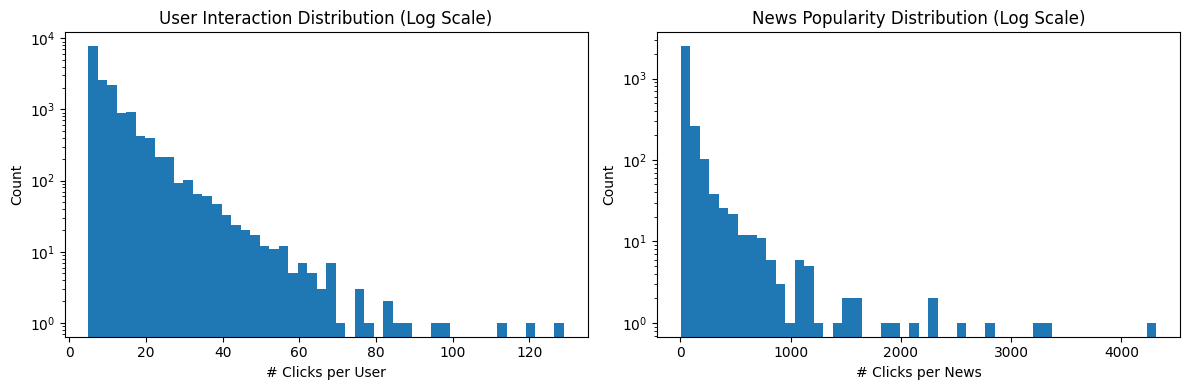

Saved: long_tail.png
Data pipeline COMPLETE!


In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
user_hist = [train_user_counts[u] for u in users]
plt.hist(user_hist, bins=50, log=True)
plt.title('User Interaction Distribution (Log Scale)')
plt.xlabel('# Clicks per User')
plt.ylabel('Count')

plt.subplot(1,2,2)
news_hist = [train_news_counts[n] for n in news]
plt.hist(news_hist, bins=50, log=True)
plt.title('News Popularity Distribution (Log Scale)')
plt.xlabel('# Clicks per News')
plt.ylabel('Count')

plt.tight_layout()
plt.savefig('long_tail.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: long_tail.png")
print("Data pipeline COMPLETE!")


### Validation before Retraining

In [ ]:
# Dev users in train?
train_user_set = set(users)
dev_user_set = set(u for u,n in filtered_dev_clicks)
overlap_pct = len(train_user_set & dev_user_set) / len(dev_user_set) * 100

print(f"Dev users in train: {overlap_pct:.1f}% ({len(train_user_set & dev_user_set)}/{len(dev_user_set)})")
print("Dev users now have train history → metrics will work!")


Dev users in train: 100.0% (1547/1547)
Dev users now have train history → metrics will work!


In [ ]:
!pip install implicit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.3/70.3 kB 4.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for implicit: filename=implicit-0.7.2-cp312-cp312-linux_x86_64.whl size=933263 sha256=c609c2bec9e15f94fc1c9a8ce3b5e4bbdf43d61b6582bbeab6f61f94ddcdf223
  Stored in directory: /root/.cache/pip/wheels/b2/00/4f/9ff8af07a0a53ac6007ea5d739da19cfe147a2df542b6899f8
Successfully built implicit


In [ ]:
import implicit
from implicit.bpr import BayesianPersonalizedRanking

# NEW mappings for filtered data
user_to_idx_filtered = {u:i for i,u in enumerate(users)}
news_to_idx_filtered = {n:i for i,n in enumerate(news)}

print("Retraining BPR on FILTERED data...")

model_filtered = BayesianPersonalizedRanking(factors=128, iterations=25, use_gpu=False)
model_filtered.fit(train_matrix)

model_save_path = "/content/drive/MyDrive/ME_PROJECT/Implementation/models"
model_filtered.save(f'{model_save_path}/bpr_filtered.npz')
print("Filtered model saved!")


Retraining BPR on FILTERED data...


  0%|          | 0/25 [00:00<?, ?it/s]

Filtered model saved!


In [ ]:
def evaluate_user_filtered(model, user_id, true_items, k=20):
    user_idx = user_to_idx_filtered.get(user_id, 0)
    scores = model.recommend(user_idx, train_matrix[user_idx], N=k,
                           filter_already_liked_items=True)
    rec_items = [news[i] for i in scores[0]]
    hits = set(rec_items) & set(true_items)
    return len(hits)/k, len(hits)/len(true_items) if true_items else 0

# Test 100 dev users with train overlap
overlap_dev_users = [u for u,n in filtered_dev_clicks if u in users][:100]
precisions, recalls = [], []

for user_id in overlap_dev_users:
    true_items = [n for u,n in filtered_dev_clicks if u==user_id]
    if len(true_items) > 0:
        p, r = evaluate_user_filtered(model_filtered, user_id, true_items)
        precisions.append(p)
        recalls.append(r)

print(f"\nFILTERED Baseline:")
print(f"Precision@20: {np.mean(precisions):.3f} ± {np.std(precisions):.3f}")
print(f"Recall@20:    {np.mean(recalls):.3f} ± {np.std(recalls):.3f}")



FILTERED Baseline:
Precision@20: 0.005 ± 0.016
Recall@20:    0.029 ± 0.104


In [ ]:
import pandas as pd

# Merge news IDs → categories
news_cols = ['news_id', 'category', 'subcategory', 'title', 'abstract', 'url', 'title_entities', 'abstract_entities']

# Reload train_news and dev_news with correct headers
train_news = pd.read_csv('data/MINDsmall_train/news.tsv', sep='\t', names=news_cols)
dev_news = pd.read_csv('data/MINDsmall_dev/news.tsv', sep='\t', names=news_cols)

train_news_dict = dict(zip(train_news['news_id'], train_news['category']))
dev_news_dict = dict(zip(dev_news['news_id'], dev_news['category']))

def category_distance(nid1, nid2):
    """Distance = 1 if different categories, 0 if same"""
    cat1 = train_news_dict.get(nid1, 'unknown')
    cat2 = train_news_dict.get(nid2, 'unknown')
    return 1.0 if cat1 != cat2 else 0.0

def compute_ild(rec_list):
    """Intra-List Diversity: avg pairwise distance"""
    if len(rec_list) < 2:
        return 0.0
    total_dist = 0
    n_pairs = 0
    for i in range(len(rec_list)):
        for j in range(i+1, len(rec_list)):
            total_dist += category_distance(rec_list[i], rec_list[j])
            n_pairs += 1
    return total_dist / n_pairs if n_pairs > 0 else 0.0

print("ILD distance function ready (category-based)")

ILD distance function ready (category-based)


In [ ]:
def evaluate_full_user(model, user_id, true_items, k=20):
    """Precision + Recall + ILD + Coverage"""
    user_idx = user_to_idx_filtered[user_id]
    scores = model.recommend(user_idx, train_matrix[user_idx], N=k,
                           filter_already_liked_items=True)
    rec_items = [news[i] for i in scores[0]]

    # Accuracy
    hits = set(rec_items) & set(true_items)
    precision = len(hits) / k
    recall = len(hits) / len(true_items) if true_items else 0

    # Diversity (ILD)
    ild = compute_ild(rec_items)

    # Coverage (unique news in recs)
    coverage = len(set(rec_items)) / len(news)

    return {
        'precision': precision,
        'recall': recall,
        'ild': ild,
        'coverage': coverage,
        'rec_items': rec_items,
        'n_hits': len(hits)
    }

# Test 50 users
overlap_dev_users = [u for u,n in filtered_dev_clicks if u in users][:50]
results = []

for user_id in overlap_dev_users:
    true_items = [n for u,n in filtered_dev_clicks if u==user_id]
    if len(true_items) > 0:
        metrics = evaluate_full_user(model_filtered, user_id, true_items)
        results.append(metrics)

# Average metrics
df_results = pd.DataFrame(results)
print("Baseline FULL Metrics:")
print(df_results[['precision', 'recall', 'ild', 'coverage']].mean().round(3))
print("\nSample rec diversity:")
print(f"ILD range: {df_results['ild'].min():.1f} - {df_results['ild'].max():.1f}")


Baseline FULL Metrics:
precision    0.003
recall       0.023
ild          0.933
coverage     0.007
dtype: float64

Sample rec diversity:
ILD range: 0.9 - 0.9


# Using lightfm

## Model Building

In [4]:
!pip install lightfm-next -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 29.1 MB/s eta 0:00:00


In [5]:
from lightfm import LightFM
from lightfm.data import Dataset

print("LightFM installed successfully!")

LightFM installed successfully!


In [6]:
import pandas as pd

behaviors_path = "/content/drive/MyDrive/ME_PROJECT/Implementation/data/MINDsmall_train/behaviors.tsv"

# Column names from MIND documentation
columns = [
    "impression_id",
    "user_id",
    "time",
    "history",
    "impressions"
]

# Load dataset
behaviors = pd.read_csv(
    behaviors_path,
    sep="\t",
    names=columns
)

# Show dataset shape
print("Dataset shape:", behaviors.shape)

# Show first rows
behaviors.head()

Dataset shape: (156965, 5)


,impression_id,user_id,time,history,impressions
0,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689-1 N35729-0
1,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...
2,3,U73700,11/14/2019 7:01:48 AM,N10732 N25792 N7563 N21087 N41087 N5445 N60384...,N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N...
3,4,U34670,11/11/2019 5:28:05 AM,N45729 N2203 N871 N53880 N41375 N43142 N33013 ...,N35729-0 N33632-0 N49685-1 N27581-0
4,5,U8125,11/12/2019 4:11:21 PM,N10078 N56514 N14904 N33740,N39985-0 N36050-0 N16096-0 N8400-1 N22407-0 N6...


In [7]:
clicked_data = []

for _, row in behaviors.iterrows():

    user = row["user_id"]
    impressions = row["impressions"].split()

    for imp in impressions:
        news_id, label = imp.split("-")

        if label == "1":
            clicked_data.append((user, news_id))

# Convert to dataframe
clicks_df = pd.DataFrame(clicked_data, columns=["user_id", "news_id"])

print("Total click interactions:", len(clicks_df))
clicks_df.head()

Total click interactions: 236344


,user_id,news_id
0,U13740,N55689
1,U91836,N17059
2,U73700,N23814
3,U34670,N49685
4,U8125,N8400


In [8]:
from lightfm.data import Dataset

# Create LightFM dataset object
dataset = Dataset()

# Fit dataset with users and items
dataset.fit(
    users=clicks_df["user_id"].unique(),
    items=clicks_df["news_id"].unique()
)

# Build interaction matrix
(interactions, weights) = dataset.build_interactions(
    [(row.user_id, row.news_id) for row in clicks_df.itertuples()]
)

print("Interaction matrix shape:", interactions.shape)
print("Total interactions:", interactions.nnz)

Interaction matrix shape: (50000, 7713)
Total interactions: 236344


In [ ]:
from lightfm import LightFM
import joblib

# Create the model
model = LightFM(
    loss="warp",        # good for implicit feedback ranking
    no_components=32,   # embedding size
    learning_rate=0.05
)

# Train the model
model.fit(
    interactions,
    epochs=10,
    num_threads=4,
    verbose=True
)

joblib.dump(model, f'{model_save_path}/lightfm_mind.joblib')

print("\nCF model trained successfully!")

Epoch: 100%|██████████| 10/10 [00:05<00:00,  1.75it/s]


CF model trained successfully!


In [9]:
# Load saved model
import joblib
from lightfm import LightFM

model_save_path = "/content/drive/MyDrive/ME_PROJECT/Implementation/models"
model: LightFM = joblib.load(f'{model_save_path}/lightfm_mind.joblib')


In [10]:
import numpy as np

# Get mapping from dataset
user_id_map, user_feature_map, item_id_map, item_feature_map = dataset.mapping()

# Reverse mapping (index → original ID)
inv_item_map = {v: k for k, v in item_id_map.items()}

# Choose a sample user
user_index = 0

# Predict scores for all items
scores = model.predict(user_index, np.arange(interactions.shape[1]))

# Get top 10 items
top_items = np.argsort(-scores)[:10]

print("Top 10 recommended news articles:")
for item in top_items:
    print(inv_item_map[item])

Top 10 recommended news articles:
N55689
N63970
N35729
N47061
N7821
N49279
N62360
N41020
N53585
N40839


### Evaluate trained model

In [ ]:
import pandas as pd

dev_beh_path = "/content/drive/MyDrive/ME_PROJECT/Implementation/data/MINDsmall_dev/behaviors.tsv"

# Column names from MIND documentation
columns = [
    "impression_id",
    "user_id",
    "time",
    "history",
    "impressions"
]

# Load dataset
dev_beh = pd.read_csv(
    dev_beh_path,
    sep="\t",
    names=columns
)

# Show dataset shape
print("Dataset shape:", dev_beh.shape)

# Show first rows
dev_beh.head()

Dataset shape: (73152, 5)


,impression_id,user_id,time,history,impressions
0,1,U80234,11/15/2019 12:37:50 PM,N55189 N46039 N51741 N53234 N11276 N264 N40716...,N28682-0 N48740-0 N31958-1 N34130-0 N6916-0 N5...
1,2,U60458,11/15/2019 7:11:50 AM,N58715 N32109 N51180 N33438 N54827 N28488 N611...,N20036-0 N23513-1 N32536-0 N46976-0 N35216-0 N...
2,3,U44190,11/15/2019 9:55:12 AM,N56253 N1150 N55189 N16233 N61704 N51706 N5303...,N36779-0 N62365-0 N58098-0 N5472-0 N13408-0 N5...
3,4,U87380,11/15/2019 3:12:46 PM,N63554 N49153 N28678 N23232 N43369 N58518 N444...,N6950-0 N60215-0 N6074-0 N11930-0 N6916-0 N248...
4,5,U9444,11/15/2019 8:25:46 AM,N51692 N18285 N26015 N22679 N55556,N5940-1 N23513-0 N49285-0 N23355-0 N19990-0 N3...


In [ ]:
dev_clicked_data = []

for _, row in dev_beh.iterrows():

    user = row["user_id"]
    impressions = row["impressions"].split()

    for imp in impressions:
        news_id, label = imp.split("-")

        if label == "1":
            dev_clicked_data.append((user, news_id))

# Convert to dataframe
dev_clicks_df = pd.DataFrame(dev_clicked_data, columns=["user_id", "news_id"])

print("Total click interactions (dev):", len(dev_clicks_df))
dev_clicks_df.head()

Total click interactions (dev): 111383


,user_id,news_id
0,U80234,N31958
1,U60458,N23513
2,U44190,N5940
3,U87380,N15347
4,U9444,N5940


In [ ]:
# dir(np)
help(np.intersect1d)

Help on _ArrayFunctionDispatcher in module numpy:

intersect1d(ar1, ar2, assume_unique=False, return_indices=False)
    Find the intersection of two arrays.

    Return the sorted, unique values that are in both of the input arrays.

    Parameters
    ----------
    ar1, ar2 : array_like
        Input arrays. Will be flattened if not already 1D.
    assume_unique : bool
        If True, the input arrays are both assumed to be unique, which
        can speed up the calculation.  If True but ``ar1`` or ``ar2`` are not
        unique, incorrect results and out-of-bounds indices could result.
        Default is False.
    return_indices : bool
        If True, the indices which correspond to the intersection of the two
        arrays are returned. The first instance of a value is used if there are
        multiple. Default is False.

        .. versionadded:: 1.15.0

    Returns
    -------
    intersect1d : ndarray
        Sorted 1D array of common and unique elements.
    comm1 : ndarra

In [ ]:
from lightfm.data import Dataset
import numpy as np

# Create a comprehensive LightFM dataset object for all users and items across train and dev data.
# This is crucial for consistent mappings between training and test interactions.
all_users = np.intersect1d(clicks_df['user_id'].unique(), dev_clicks_df['user_id'].unique())
all_news = np.intersect1d(clicks_df['news_id'].unique(), dev_clicks_df['news_id'].unique())

full_dataset_mapper = Dataset()
full_dataset_mapper.fit(users=all_users, items=all_news)

# Build train_interactions from clicks_df (training data)
train_interactions, _ = full_dataset_mapper.build_interactions(
    [(u, i) for u, i in zip(clicks_df.user_id, clicks_df.news_id)]
)

# Build test_interactions from dev_clicks_df (development/test data)
test_interactions, _ = full_dataset_mapper.build_interactions(
    [(u, i) for u, i in zip(dev_clicks_df.user_id, dev_clicks_df.news_id)]
)

print("Train interactions shape:", train_interactions.shape)
print("Test interactions shape:", test_interactions.shape)
print(f"Number of interactions in training set: {train_interactions.nnz}")
print(f"Number of interactions in test set: {test_interactions.nnz}")

ValueError: User id U13740 not in user id mapping. Make sure you call the fit method.

In [ ]:
from lightfm.evaluation import precision_at_k, recall_at_k

# Evaluate with check_intersections=False to allow for common data
prec20_train = precision_at_k(model, train_interactions, train_interactions=train_interactions, k=20, check_intersections=False).mean()
prec20_test = precision_at_k(model, test_interactions, train_interactions=train_interactions, k=20, check_intersections=True).mean()
rec20_train = recall_at_k(model, train_interactions, train_interactions=train_interactions, k=20, check_intersections=False).mean()
rec20_test = recall_at_k(model, test_interactions, train_interactions=train_interactions, k=20, check_intersections=True).mean()

print(f"Prec@20 Train: {prec20_train:.4f}, Test: {prec20_test:.4f}")
print(f"Rec@20 Train: {rec20_train:.4f}, Test: {rec20_test:.4f}")

ValueError: The user feature matrix specifies more features than there are estimated feature embeddings: 50000 vs 94057.

## ADF Preparation

In [11]:
# Path to news metadata
news_path = "/content/drive/MyDrive/ME_PROJECT/Implementation/data/MINDsmall_train/news.tsv"

news_columns = [
    "news_id",
    "category",
    "subcategory",
    "title",
    "abstract",
    "url",
    "title_entities",
    "abstract_entities"
]

news_df = pd.read_csv(
    news_path,
    sep="\t",
    names=news_columns
)

print("News dataset shape:", news_df.shape)

news_df.head()

News dataset shape: (51282, 8)


,news_id,category,subcategory,title,abstract,url,title_entities,abstract_entities
0,N55528,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the...",https://assets.msn.com/labs/mind/AAGH0ET.html,"[{""Label"": ""Prince Philip, Duke of Edinburgh"",...",[]
1,N19639,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...,https://assets.msn.com/labs/mind/AAB19MK.html,"[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik...","[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik..."
2,N61837,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...,https://assets.msn.com/labs/mind/AAJgNsz.html,[],"[{""Label"": ""Ukraine"", ""Type"": ""G"", ""WikidataId..."
3,N53526,health,voices,I Was An NBA Wife. Here's How It Affected My M...,"I felt like I was a fraud, and being an NBA wi...",https://assets.msn.com/labs/mind/AACk2N6.html,[],"[{""Label"": ""National Basketball Association"", ..."
4,N38324,health,medical,"How to Get Rid of Skin Tags, According to a De...","They seem harmless, but there's a very good re...",https://assets.msn.com/labs/mind/AAAKEkt.html,"[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI...","[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI..."


In [12]:
# Fill missing values to avoid errors
news_df["title"] = news_df["title"].fillna("")
news_df["abstract"] = news_df["abstract"].fillna("")

# Combine title and abstract
news_df["text"] = news_df["title"] + " " + news_df["abstract"]

# Keep only columns we need for now
news_text_df = news_df[["news_id", "text"]]

print("Prepared text dataset shape:", news_text_df.shape)

news_text_df.head()

Prepared text dataset shape: (51282, 2)


,news_id,text
0,N55528,"The Brands Queen Elizabeth, Prince Charles, an..."
1,N19639,50 Worst Habits For Belly Fat These seemingly ...
2,N61837,The Cost of Trump's Aid Freeze in the Trenches...
3,N53526,I Was An NBA Wife. Here's How It Affected My M...
4,N38324,"How to Get Rid of Skin Tags, According to a De..."


In [13]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    max_features=5000,     # limit vocabulary size
    stop_words="english",  # remove common words
    min_df=5               # ignore very rare words
)

doc_term_matrix = vectorizer.fit_transform(news_text_df["text"])

print("Document-Term Matrix shape:", doc_term_matrix.shape)

Document-Term Matrix shape: (51282, 5000)


## LDA decomposition

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation

# number of topics
n_topics = 20

lda_model = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    learning_method="batch",
    verbose=1
)

lda_matrix = lda_model.fit_transform(doc_term_matrix)

print("LDA topic matrix shape:", lda_matrix.shape)

iteration: 1 of max_iter: 10
iteration: 2 of max_iter: 10
iteration: 3 of max_iter: 10
iteration: 4 of max_iter: 10
iteration: 5 of max_iter: 10
iteration: 6 of max_iter: 10
iteration: 7 of max_iter: 10
iteration: 8 of max_iter: 10
iteration: 9 of max_iter: 10
iteration: 10 of max_iter: 10
LDA topic matrix shape: (51282, 20)


In [ ]:
import joblib
joblib.dump(lda_matrix, f'{model_save_path}/lda_matrix.joblib')

['/content/drive/MyDrive/ME_PROJECT/Implementation/models/lda_matrix.joblib']

In [14]:
# Load saved lda matrix
lda_matrix = joblib.load(f'{model_save_path}/lda_matrix.joblib')

## UMAP embeddings

In [ ]:
!pip install umap-learn -q

In [ ]:
import umap

umap_model = umap.UMAP(
    n_components=5,
    random_state=42
)

umap_embeddings = umap_model.fit_transform(lda_matrix)

print("UMAP embedding shape:", umap_embeddings.shape)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embedding shape: (51282, 5)


In [ ]:
import joblib
joblib.dump(umap_embeddings, f'{model_save_path}/umap_embeddings.joblib')

['/content/drive/MyDrive/ME_PROJECT/Implementation/models/umap_embeddings.joblib']

In [15]:
# Load saved lda matrix
umap_embeddings = joblib.load(f'{model_save_path}/umap_embeddings.joblib')

## Clustering

In [ ]:
!pip install hdbscan -q

In [ ]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=50,   # controls cluster size
    metric='euclidean'
)

clusters = clusterer.fit_predict(umap_embeddings)

print("Total clusters (excluding noise):",
      len(set(clusters)) - (1 if -1 in clusters else 0))
print("Noise points:", list(clusters).count(-1))

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


Total clusters (excluding noise): 29
Noise points: 2053


In [ ]:
import joblib
joblib.dump(clusters, f'{model_save_path}/clusters.joblib')

['/content/drive/MyDrive/ME_PROJECT/Implementation/models/clusters.joblib']

In [16]:
# load saved clusters
clusters = joblib.load(f'{model_save_path}/clusters.joblib')

In [17]:
news_text_df["cluster"] = clusters

news_text_df.head()

/tmp/ipykernel_9360/1227862736.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  news_text_df["cluster"] = clusters


,news_id,text,cluster
0,N55528,"The Brands Queen Elizabeth, Prince Charles, an...",27
1,N19639,50 Worst Habits For Belly Fat These seemingly ...,27
2,N61837,The Cost of Trump's Aid Freeze in the Trenches...,27
3,N53526,I Was An NBA Wife. Here's How It Affected My M...,27
4,N38324,"How to Get Rid of Skin Tags, According to a De...",27


In [ ]:
news_text_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51282 entries, 0 to 51281
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   news_id  51282 non-null  object
 1   text     51282 non-null  object
 2   cluster  51282 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.2+ MB


In [ ]:
news_text_df['cluster'].nunique()

30

In [ ]:
import joblib
joblib.dump(news_text_df, f'{model_save_path}/news_text_df.joblib')

['/content/drive/MyDrive/ME_PROJECT/Implementation/models/news_text_df.joblib']

In [18]:
# load saved news_text_df
news_text_df = joblib.load(f'{model_save_path}/news_text_df.joblib')

In [ ]:
# Create mapping: news_id → cluster
news_cluster_map = dict(
    zip(news_text_df["news_id"], news_text_df["cluster"])
)

# Test mapping with a few examples
sample_items = list(news_cluster_map.items())[:5]

print("Sample news_id → cluster mapping:")
for item in sample_items:
    print(item)

Sample news_id → cluster mapping:
('N55528', 27)
('N19639', 27)
('N61837', 27)
('N53526', 27)
('N38324', 27)


In [ ]:
import joblib
joblib.dump(news_cluster_map, f'{model_save_path}/news_cluster_map.joblib')

['/content/drive/MyDrive/ME_PROJECT/Implementation/models/news_cluster_map.joblib']

In [19]:
# load saved news_cluster_map
news_cluster_map = joblib.load(f'{model_save_path}/news_cluster_map.joblib')

In [ ]:
# Check cluster distribution
import collections

cluster_counts = collections.Counter(news_cluster_map.values())

print("Top 10 cluster sizes:")
for cluster, count in cluster_counts.most_common(10):
    print(f"Cluster {cluster}: {count} items")

Top 10 cluster sizes:
Cluster 27: 46767 items
Cluster -1: 2053 items
Cluster 23: 261 items
Cluster 6: 199 items
Cluster 2: 174 items
Cluster 14: 135 items
Cluster 19: 126 items
Cluster 25: 102 items
Cluster 21: 95 items
Cluster 24: 91 items


## ADF incrementally

### Naive ad ranking

In [ ]:
def ad_rerank(user_index, model, interactions, inv_item_map,
              news_cluster_map, alpha=0.7, top_k=10):

    # Step 1: Get CF scores
    scores = model.predict(user_index, np.arange(interactions.shape[1]))

    # Step 2: Sort items by CF score
    ranked_items = np.argsort(-scores)

    selected_items = []
    cluster_counts = {}

    for item in ranked_items:

        news_id = inv_item_map[item]
        cluster = news_cluster_map.get(news_id, -1)

        # diversity penalty
        penalty = cluster_counts.get(cluster, 0)

        # combined score
        final_score = alpha * scores[item] - (1 - alpha) * penalty

        selected_items.append((item, final_score, cluster))

        # update cluster count
        cluster_counts[cluster] = penalty + 1

        if len(selected_items) >= top_k:
            break

    return selected_items

In [ ]:
# Test for one user
user_index = 0

ad_results = ad_rerank(
    user_index,
    model,
    interactions,
    inv_item_map,
    news_cluster_map,
    alpha=0.7,
    top_k=10
)

print("AD Re-ranked recommendations:")
for item, score, cluster in ad_results:
    print(inv_item_map[item], "Cluster:", cluster)

AD Re-ranked recommendations:
N55689 Cluster: 27
N63970 Cluster: 27
N35729 Cluster: 27
N47061 Cluster: 27
N7821 Cluster: 27
N49279 Cluster: 27
N62360 Cluster: 27
N41020 Cluster: 27
N53585 Cluster: -1
N40839 Cluster: 27


### Greedy ad ranking

In [25]:
def ad_rerank_greedy(user_index, model, interactions, inv_item_map,
                     news_cluster_map, alpha=0.7, top_k=10):

    scores = model.predict(user_index, np.arange(interactions.shape[1]))
    ranked_items = list(np.argsort(-scores))

    selected_items = []
    cluster_counts = {}

    for _ in range(top_k):

        best_item = None
        best_score = -np.inf
        best_cluster = None

        for item in ranked_items:

            news_id = inv_item_map[item]
            cluster = news_cluster_map.get(news_id, -1)

            penalty = cluster_counts.get(cluster, 0)

            final_score = alpha * scores[item] - (1 - alpha) * penalty

            if final_score > best_score:
                best_score = final_score
                best_item = item
                best_cluster = cluster

        # add best item
        selected_items.append((best_item, best_score, best_cluster))

        # update cluster counts
        cluster_counts[best_cluster] = cluster_counts.get(best_cluster, 0) + 1

        # remove selected item
        ranked_items.remove(best_item)

    return selected_items

In [ ]:
# Test for one user
ad_results = ad_rerank_greedy(
    user_index=0,
    model=model,
    interactions=interactions,
    inv_item_map=inv_item_map,
    news_cluster_map=news_cluster_map,
    alpha=0.7,
    top_k=10
)

print("AD (Greedy) recommendations:")
for item, score, cluster in ad_results:
    print(inv_item_map[item], "Cluster:", cluster)

AD (Greedy) recommendations:
N55689 Cluster: 27
N53585 Cluster: -1
N63970 Cluster: 27
N35729 Cluster: 27
N42634 Cluster: 23
N61145 Cluster: 2
N45523 Cluster: -1
N47061 Cluster: 27
N7809 Cluster: 15
N7754 Cluster: 8


### Greedy AF rerank

In [24]:
def af_rerank_greedy(user_index, model, interactions,
                     inv_item_map, news_cluster_map, top_k=10):

    scores = model.predict(user_index, np.arange(interactions.shape[1]))
    ranked_items = list(np.argsort(-scores))

    selected_items = []
    cluster_counts = {}

    # compute number of clusters (excluding noise)
    valid_clusters = [c for c in set(news_cluster_map.values()) if c != -1]
    num_clusters = len(valid_clusters)

    target_per_cluster = top_k / num_clusters

    for _ in range(top_k):

        best_item = None
        best_score = -np.inf
        best_cluster = None

        for item in ranked_items:

            news_id = inv_item_map[item]
            cluster = news_cluster_map.get(news_id, -1)

            count = cluster_counts.get(cluster, 0)

            # fairness penalty
            if count > target_per_cluster:
                penalty = 5  # strong penalty
            else:
                penalty = 0

            final_score = scores[item] - penalty

            if final_score > best_score:
                best_score = final_score
                best_item = item
                best_cluster = cluster

        selected_items.append((best_item, best_score, best_cluster))

        cluster_counts[best_cluster] = cluster_counts.get(best_cluster, 0) + 1

        ranked_items.remove(best_item)

    return selected_items

In [ ]:
# Test for a single user
af_results = af_rerank_greedy(
    user_index=0,
    model=model,
    interactions=interactions,
    inv_item_map=inv_item_map,
    news_cluster_map=news_cluster_map,
    top_k=10
)

print("AF recommendations:")
for item, score, cluster in af_results:
    print(inv_item_map[item], "Cluster:", cluster)

AF recommendations:
N55689 Cluster: 27
N53585 Cluster: -1
N42634 Cluster: 23
N61145 Cluster: 2
N7809 Cluster: 15
N7754 Cluster: 8
N11869 Cluster: 24
N22825 Cluster: 6
N33755 Cluster: 20
N64174 Cluster: 9


### Greedy ADF (AD+AF)

In [26]:
def adf_rerank_greedy(user_index, model, interactions, inv_item_map,
                      news_cluster_map, alpha=0.7, top_k=10):

    scores = model.predict(user_index, np.arange(interactions.shape[1]))
    ranked_items = list(np.argsort(-scores))

    selected_items = []
    cluster_counts = {}

    # cluster info
    valid_clusters = [c for c in set(news_cluster_map.values()) if c != -1]
    num_clusters = len(valid_clusters)
    target_per_cluster = top_k / num_clusters

    for _ in range(top_k):

        best_item = None
        best_score = -np.inf
        best_cluster = None

        for item in ranked_items:

            news_id = inv_item_map[item]
            cluster = news_cluster_map.get(news_id, -1)

            count = cluster_counts.get(cluster, 0)

            # diversity penalty
            diversity_penalty = count

            # fairness penalty
            fairness_penalty = max(0, count - target_per_cluster)

            # combined score
            final_score = (
                alpha * scores[item]
                - (1 - alpha) * diversity_penalty
                - (1 - alpha) * fairness_penalty
            )

            if final_score > best_score:
                best_score = final_score
                best_item = item
                best_cluster = cluster

        selected_items.append((best_item, best_score, best_cluster))

        cluster_counts[best_cluster] = cluster_counts.get(best_cluster, 0) + 1

        ranked_items.remove(best_item)

    return selected_items

In [ ]:
# Test for a user
adf_results = adf_rerank_greedy(
    user_index=0,
    model=model,
    interactions=interactions,
    inv_item_map=inv_item_map,
    news_cluster_map=news_cluster_map,
    alpha=0.7,
    top_k=10
)

print("ADF recommendations:")
for item, score, cluster in adf_results:
    print(inv_item_map[item], "Cluster:", cluster)

ADF recommendations:
N55689 Cluster: 27
N53585 Cluster: -1
N63970 Cluster: 27
N42634 Cluster: 23
N61145 Cluster: 2
N7809 Cluster: 15
N7754 Cluster: 8
N11869 Cluster: 24
N22825 Cluster: 6
N45523 Cluster: -1


# Metrics

In [ ]:
from collections import defaultdict

user_clicks = defaultdict(set)

for row in clicks_df.itertuples():
    user_clicks[row.user_id].add(row.news_id)

print("Ground truth built for users:", len(user_clicks))

Ground truth built for users: 50000


In [ ]:
import joblib
# Save Ground truth for user clicks
joblib.dump(user_clicks, f'{model_save_path}/user_clicks.joblib')

['/content/drive/MyDrive/ME_PROJECT/Implementation/models/user_clicks.joblib']

In [20]:
# Load saved ground truth for users
user_clicks = joblib.load(f'{model_save_path}/user_clicks.joblib')

## Precision@k

In [21]:
def precision_at_k(recommended_items, ground_truth, k=10):

    recommended_k = recommended_items[:k]

    hits = 0
    for item in recommended_k:
        if item in ground_truth:
            hits += 1

    return hits / k

In [ ]:
# Example test
recommended = ["A", "B", "C", "D", "E"]
ground_truth = ["B", "E"]

print("Precision@5:", precision_at_k(recommended, ground_truth, k=5))

Precision@5: 0.4


In [22]:
def get_cf_recommendations(user_index, model, interactions, inv_item_map, top_k=10):

    scores = model.predict(user_index, np.arange(interactions.shape[1]))
    ranked_items = np.argsort(-scores)[:top_k]

    return [inv_item_map[item] for item in ranked_items]

In [23]:
import random

def evaluate_precision(model, interactions, dataset,
                       inv_item_map, news_cluster_map,
                       user_clicks, method="cf",
                       alpha=0.7, num_users=100):

    user_id_map, _, _, _ = dataset.mapping()
    inv_user_map = {v: k for k, v in user_id_map.items()}

    user_indices = list(inv_user_map.keys())
    sampled_users = random.sample(user_indices, num_users)

    precisions = []

    for user_index in sampled_users:

        user_id = inv_user_map[user_index]
        ground_truth = user_clicks.get(user_id, set())

        if len(ground_truth) == 0:
            continue

        # get recommendations
        if method == "cf":
            recs = get_cf_recommendations(user_index, model,
                                          interactions, inv_item_map)

        elif method == "ad":
            results = ad_rerank_greedy(user_index, model, interactions,
                                       inv_item_map, news_cluster_map, alpha)
            recs = [inv_item_map[item] for item, _, _ in results]

        elif method == "af":
            results = af_rerank_greedy(user_index, model, interactions,
                                       inv_item_map, news_cluster_map)
            recs = [inv_item_map[item] for item, _, _ in results]

        elif method == "adf":
            results = adf_rerank_greedy(user_index, model, interactions,
                                        inv_item_map, news_cluster_map, alpha)
            recs = [inv_item_map[item] for item, _, _ in results]

        else:
            continue

        prec = precision_at_k(recs, ground_truth, k=10)
        precisions.append(prec)

    return sum(precisions) / len(precisions)

In [27]:
cf_score = evaluate_precision(model, interactions, dataset, inv_item_map, news_cluster_map, user_clicks, method="cf")
ad_score = evaluate_precision(model, interactions, dataset, inv_item_map, news_cluster_map, user_clicks, method="ad")
af_score = evaluate_precision(model, interactions, dataset, inv_item_map, news_cluster_map, user_clicks, method="af")
adf_score = evaluate_precision(model, interactions, dataset, inv_item_map, news_cluster_map, user_clicks, method="adf")

print("Precision@10 Results:")
print("CF :", cf_score)
print("AD :", ad_score)
print("AF :", af_score)
print("ADF:", adf_score)

Precision@10 Results:
CF : 0.133
AD : 0.1
AF : 0.04
ADF: 0.081


## ILD (Intra-List Diversity)

In [28]:
from itertools import combinations

def ild_score(recommended_items, news_cluster_map):

    if len(recommended_items) < 2:
        return 0

    pairs = list(combinations(recommended_items, 2))

    dissimilarities = []

    for item1, item2 in pairs:
        c1 = news_cluster_map.get(item1, -1)
        c2 = news_cluster_map.get(item2, -1)

        if c1 == c2:
            dissimilarities.append(0)
        else:
            dissimilarities.append(1)

    return sum(dissimilarities) / len(dissimilarities)

In [29]:
def evaluate_ild(model, interactions, dataset, inv_item_map,
                 news_cluster_map, method="cf", alpha=0.7, num_users=100):

    user_id_map, _, _, _ = dataset.mapping()
    inv_user_map = {v: k for k, v in user_id_map.items()}

    user_indices = list(inv_user_map.keys())
    sampled_users = random.sample(user_indices, num_users)

    ild_scores = []

    for user_index in sampled_users:

        if method == "cf":
            recs = get_cf_recommendations(user_index, model,
                                          interactions, inv_item_map)

        elif method == "ad":
            results = ad_rerank_greedy(user_index, model, interactions,
                                       inv_item_map, news_cluster_map, alpha)
            recs = [inv_item_map[item] for item, _, _ in results]

        elif method == "af":
            results = af_rerank_greedy(user_index, model, interactions,
                                       inv_item_map, news_cluster_map)
            recs = [inv_item_map[item] for item, _, _ in results]

        elif method == "adf":
            results = adf_rerank_greedy(user_index, model, interactions,
                                        inv_item_map, news_cluster_map, alpha)
            recs = [inv_item_map[item] for item, _, _ in results]

        else:
            continue

        ild = ild_score(recs, news_cluster_map)
        ild_scores.append(ild)

    return sum(ild_scores) / len(ild_scores)

In [31]:
cf_ild = evaluate_ild(model, interactions, dataset,
                      inv_item_map, news_cluster_map, method="cf")
ad_ild = evaluate_ild(model, interactions, dataset,
                      inv_item_map, news_cluster_map, method="ad")
af_ild = evaluate_ild(model, interactions, dataset,
                      inv_item_map, news_cluster_map, method="af")
adf_ild = evaluate_ild(model, interactions, dataset,
                       inv_item_map, news_cluster_map, method="adf")

print("ILD Results:")
print("CF :", cf_ild)
print("AD :", ad_ild)
print("AF :", af_ild)
print("ADF:", adf_ild)

ILD Results:
CF : 0.12355555555555556
AD : 0.8277777777777777
AF : 1.0
ADF: 0.9162222222222222


## Coverage + Fairness Metrics (Gini / Entropy)

In [32]:
def evaluate_coverage(model, interactions, dataset, inv_item_map, news_cluster_map, method="cf", alpha=0.7, num_users=100):

    user_id_map, _, _, _ = dataset.mapping()
    inv_user_map = {v: k for k, v in user_id_map.items()}

    user_indices = list(inv_user_map.keys())
    sampled_users = random.sample(user_indices, num_users)

    recommended_items = set()

    for user_index in sampled_users:

        if method == "cf":
            recs = get_cf_recommendations(user_index, model, interactions, inv_item_map)

        elif method == "ad":
            results = ad_rerank_greedy(user_index, model, interactions, inv_item_map, news_cluster_map, alpha)
            recs = [inv_item_map[item] for item, _, _ in results]

        elif method == "af":
            results = af_rerank_greedy(user_index, model, interactions, inv_item_map, news_cluster_map)
            recs = [inv_item_map[item] for item, _, _ in results]

        elif method == "adf":
            results = adf_rerank_greedy(user_index, model, interactions, inv_item_map, news_cluster_map, alpha)
            recs = [inv_item_map[item] for item, _, _ in results]

        else:
            continue

        recommended_items.update(recs)

    return len(recommended_items)

In [34]:
import numpy as np

def gini_index(exposures):
    exposures = np.array(exposures)
    exposures = exposures + 1e-9  # avoid division by zero

    exposures_sorted = np.sort(exposures)
    n = len(exposures)

    index = np.arange(1, n + 1)

    return (np.sum((2 * index - n - 1) * exposures_sorted)) / (n * np.sum(exposures_sorted))

In [35]:
def entropy(exposures):
    exposures = np.array(exposures)
    probs = exposures / np.sum(exposures)

    return -np.sum(probs * np.log(probs + 1e-9))

In [37]:
from collections import defaultdict

def get_exposure_distribution(model, interactions,
                              dataset, inv_item_map,
                              news_cluster_map, method="cf",
                              alpha=0.7, num_users=100):

    user_id_map, _, _, _ = dataset.mapping()
    inv_user_map = {v: k for k, v in user_id_map.items()}

    user_indices = list(inv_user_map.keys())
    sampled_users = random.sample(user_indices, num_users)

    exposure_counts = defaultdict(int)

    for user_index in sampled_users:

        if method == "cf":
            recs = get_cf_recommendations(user_index, model,
                                          interactions, inv_item_map)

        elif method == "ad":
            results = ad_rerank_greedy(user_index, model, interactions,
                                       inv_item_map, news_cluster_map, alpha)
            recs = [inv_item_map[item] for item, _, _ in results]

        elif method == "af":
            results = af_rerank_greedy(user_index, model, interactions,
                                       inv_item_map, news_cluster_map)
            recs = [inv_item_map[item] for item, _, _ in results]

        elif method == "adf":
            results = adf_rerank_greedy(user_index, model, interactions,
                                        inv_item_map, news_cluster_map, alpha)
            recs = [inv_item_map[item] for item, _, _ in results]

        else:
            continue

        for item in recs:
            exposure_counts[item] += 1

    return list(exposure_counts.values())

In [39]:
# Coverage
cf_cov = evaluate_coverage(model, interactions, dataset, inv_item_map, news_cluster_map, "cf")
ad_cov = evaluate_coverage(model, interactions, dataset, inv_item_map, news_cluster_map, "ad")
af_cov = evaluate_coverage(model, interactions, dataset, inv_item_map, news_cluster_map, "af")
adf_cov = evaluate_coverage(model, interactions, dataset, inv_item_map, news_cluster_map, "adf")

print("Coverage:")
print("CF :", cf_cov)
print("AD :", ad_cov)
print("AF :", af_cov)
print("ADF:", adf_cov)

# Gini & Entropy
cf_exp = get_exposure_distribution(model, interactions, dataset, inv_item_map, news_cluster_map, "cf")
ad_exp = get_exposure_distribution(model, interactions, dataset, inv_item_map, news_cluster_map, "ad")
af_exp = get_exposure_distribution(model, interactions, dataset, inv_item_map, news_cluster_map, "af")
adf_exp = get_exposure_distribution(model, interactions, dataset, inv_item_map, news_cluster_map, "adf")

print("\nGini:")
print("CF :", gini_index(cf_exp))
print("AD :", gini_index(ad_exp))
print("AF :", gini_index(af_exp))
print("ADF:", gini_index(adf_exp))

print("\nEntropy:")
print("CF :", entropy(cf_exp))
print("AD :", entropy(ad_exp))
print("AF :", entropy(af_exp))
print("ADF:", entropy(adf_exp))

Coverage:
CF : 156
AD : 135
AF : 111
ADF: 144

Gini:
CF : 0.7140969695791437
AD : 0.685121951107152
AF : 0.6554234233506716
ADF: 0.667906976658026

Entropy:
CF : 3.9652074431616144
AD : 4.102292868072264
AF : 3.893171603218908
ADF: 3.97401269217002


# α Sweep Graphs

In [40]:
alphas = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

In [43]:
precision_scores = []
ild_scores = []
gini_scores = []
entropy_scores = []

for alpha in alphas:

    print(f"Running alpha = {alpha}")

    # Precision
    p = evaluate_precision(
        model, interactions, dataset, inv_item_map, news_cluster_map,
        user_clicks, method="adf", alpha=alpha, num_users=300
    )

    # ILD
    ild = evaluate_ild(
        model, interactions, dataset, inv_item_map, news_cluster_map,
        method="adf", alpha=alpha, num_users=300
    )

    # Exposure
    exp = get_exposure_distribution(
        model, interactions, dataset, inv_item_map, news_cluster_map,
        method="adf", alpha=alpha, num_users=300
    )

    g = gini_index(exp)
    e = entropy(exp)

    precision_scores.append(p)
    ild_scores.append(ild)
    gini_scores.append(g)
    entropy_scores.append(e)

Running alpha = 0.0
Running alpha = 0.2
Running alpha = 0.4
Running alpha = 0.6
Running alpha = 0.8
Running alpha = 1.0


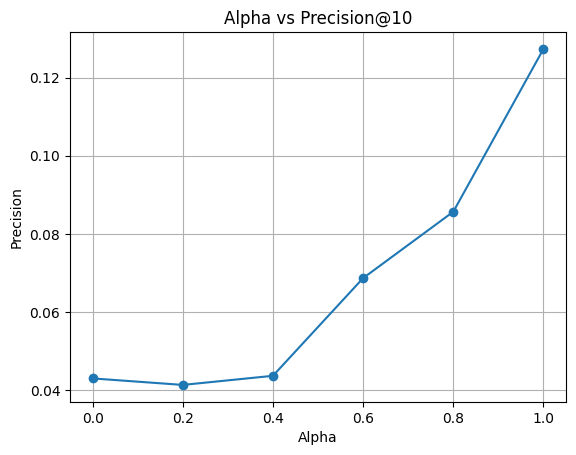

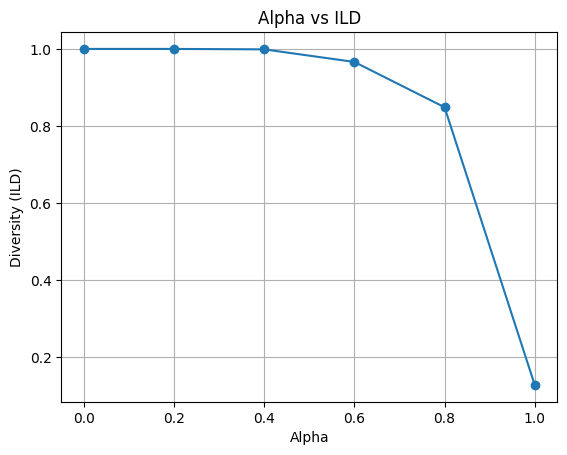

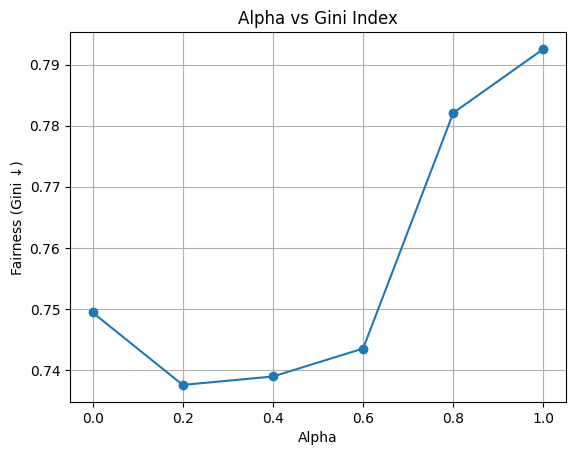

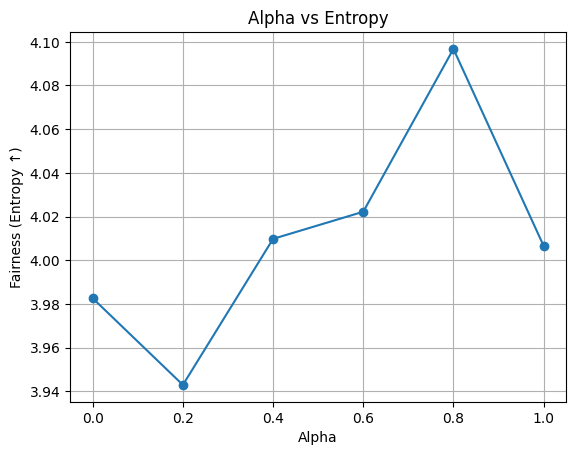

In [44]:
import matplotlib.pyplot as plt

# Precision
plt.figure()
plt.plot(alphas, precision_scores, marker='o')
plt.title("Alpha vs Precision@10")
plt.xlabel("Alpha")
plt.ylabel("Precision")
plt.grid()
plt.show()

# ILD
plt.figure()
plt.plot(alphas, ild_scores, marker='o')
plt.title("Alpha vs ILD")
plt.xlabel("Alpha")
plt.ylabel("Diversity (ILD)")
plt.grid()
plt.show()

# Gini
plt.figure()
plt.plot(alphas, gini_scores, marker='o')
plt.title("Alpha vs Gini Index")
plt.xlabel("Alpha")
plt.ylabel("Fairness (Gini ↓)")
plt.grid()
plt.show()

# Entropy
plt.figure()
plt.plot(alphas, entropy_scores, marker='o')
plt.title("Alpha vs Entropy")
plt.xlabel("Alpha")
plt.ylabel("Fairness (Entropy ↑)")
plt.grid()
plt.show()